In [53]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Add, Activation
from tensorflow.keras.regularizers import l2
from scipy.spatial import ConvexHull
from matplotlib.path import Path
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers

import os
import random
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.initializers import GlorotUniform
from sklearn.neighbors import LocalOutlierFactor
from tensorflow.keras.layers import Input, Dense, Activation, Add, BatchNormalization, LeakyReLU
from scipy.spatial.distance import mahalanobis
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from adjustText import adjust_text 

In [54]:
df= pd.read_csv("dataset.csv",index_col=0)
df = df[df['MOF_ID'] != 'hMOF-1002818']

In [55]:
metals=['chem_metal_Sc', 'chem_metal_Ti',
       'chem_metal_V', 'chem_metal_Cr', 'chem_metal_Mn', 'chem_metal_Fe',
       'chem_metal_Co', 'chem_metal_Ni', 'chem_metal_Cu', 'chem_metal_Zn',
       'chem_metal_Y', 'chem_metal_Zr', 'chem_metal_Nb', 'chem_metal_Mo',
       'chem_metal_Tc', 'chem_metal_Ru', 'chem_metal_Rh', 'chem_metal_Pd',
       'chem_metal_Ag', 'chem_metal_Cd', 'chem_metal_Hf', 'chem_metal_Ta',
       'chem_metal_W', 'chem_metal_Re', 'chem_metal_Os', 'chem_metal_Ir',
       'chem_metal_Pt', 'chem_metal_Au', 'chem_metal_Hg', 'chem_metal_Al',
       'chem_metal_Ga', 'chem_metal_In', 'chem_metal_Sn', 'chem_metal_Pb',
       'chem_metal_Bi', 'chem_metal_La', 'chem_metal_Ce', 'chem_metal_Pr',
       'chem_metal_Nd', 'chem_metal_Sm', 'chem_metal_Eu', 'chem_metal_Gd',
       'chem_metal_Tb', 'chem_metal_Dy', 'chem_metal_Ho', 'chem_metal_Er',
       'chem_metal_Tm', 'chem_metal_Yb', 'chem_metal_Lu',]
nonmetals=['chem_num_atoms',
 'chem_volume',
 'chem_density',
 'chem_avg_atomic_mass',
 'chem_avg_electronegativity',
 'chem_electronegativity_variance',
 'chem_metal_fraction',
 'chem_num_unique_elements',
 'chem_metal_atom_count',
 'chem_volume_per_atom',
 'geo_surface_area_m2g',
 'geo_surface_area_m2cm3',
 'geo_void_fraction',
 'geo_pld',
 'geo_lcd',
 'link_linker_atom_fraction',
 'link_linker_bond_length_mean',
 'link_linker_bond_length_std',
 'link_metal_coord_number_mean',
 'topo_avg_node_connectivity',
 'topo_avg_ring_size',
 'topo_coordination_number_mean',
 'topo_degree_assortativity',
 'topo_degree_centrality_mean',
 'topo_graph_density',
 'topo_graph_entropy',
 'topo_graph_transitivity',
 'topo_largest_cc_fraction',
 'topo_node_connectivity_std',
 'topo_num_connected_components',
 'topo_num_edges',
 'topo_num_nodes']
features=nonmetals+metals

In [56]:
df_cleaned = df.dropna()
df_cleaned = df_cleaned.reset_index()
print("NaNs in X_scaled:", df_cleaned.isnull().sum().sum())

NaNs in X_scaled: 0


In [57]:
X_train_val_full, X_test_full = train_test_split(df_cleaned, test_size=0.2, random_state=4)
X_train_full, X_val_full = train_test_split(X_train_val_full, test_size=0.25, random_state=42)

scaler_X = StandardScaler()
scaler_X.fit(X_train_full[nonmetals])

X_train_nonmetal_np = scaler_X.transform(X_train_full[nonmetals])
X_train_nonmetal = pd.DataFrame(X_train_nonmetal_np, index=X_train_full.index, columns=nonmetals)
X_train = pd.concat([X_train_nonmetal, X_train_full[metals]], axis=1)

X_val_nonmetal_np = scaler_X.transform(X_val_full[nonmetals])
X_val_nonmetal = pd.DataFrame(X_val_nonmetal_np, index=X_val_full.index, columns=nonmetals)
X_val = pd.concat([X_val_nonmetal, X_val_full[metals]], axis=1)

X_test_nonmetal_np = scaler_X.transform(X_test_full[nonmetals])
X_test_nonmetal = pd.DataFrame(X_test_nonmetal_np, index=X_test_full.index, columns=nonmetals)
X_test = pd.concat([X_test_nonmetal, X_test_full[metals]], axis=1)

X_full_dataset=pd.concat([X_train, X_val,X_test], axis=0)

In [58]:
output_dir='Results'

In [87]:
input_dim = 81

latent_dim=16
step_size=2

print(f"\n===== Training Model: Latent Dim = {latent_dim}, Step Size = {step_size} =====\n")

encoder_neurons = list(range(input_dim - step_size, latent_dim, -step_size))
decoder_neurons = encoder_neurons[::-1]

input_layer = Input(shape=(input_dim,))
x = input_layer

for neurons in encoder_neurons:
    x = Dense(neurons)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

encoded = Dense(latent_dim, name='latent_space')(x)
x = encoded

for neurons in decoder_neurons:
    x = Dense(neurons)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

output_layer = Dense(input_dim, activation='linear')(x)
autoencoder = Model(inputs=input_layer, outputs=output_layer)

optimizer = Adam(learning_rate=0.001)
autoencoder.compile(optimizer=optimizer, loss='mse')

early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=0)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-5, verbose=0)

train_ds = tf.data.Dataset.from_tensor_slices((X_train, X_train)).batch(3200).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, X_val)).batch(3200).prefetch(tf.data.AUTOTUNE)

history = autoencoder.fit(
    train_ds,
    epochs=200,
    validation_data=val_ds,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
pd.DataFrame(history.history).to_csv(f'{output_dir}/loss_{latent_dim}_{step_size}.csv')


===== Training Model: Latent Dim = 16, Step Size = 2 =====



In [88]:
autoencoder.save(f'{output_dir}/model.keras')

In [89]:
m=4

params = {
    # Font family
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],

    # Font sizes
    "axes.labelsize": 10*m,
    "font.size": 10*m,
    "legend.fontsize": 10*m,
    "xtick.labelsize": 9*m,
    "ytick.labelsize": 9*m,

    # Style for axis labels (xlabel, ylabel)
    'axes.labelweight': 'bold',
    'axes.labelcolor': 'black',

    # General styles for other elements
    'font.weight': 'bold',       # Makes title, etc., bold
    'xtick.color': 'black',      # Sets tick label color
    'ytick.color': 'black',
    'legend.labelcolor': 'black'
}

plt.rcParams.update(params)

In [90]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_ran = range(1, len(loss) + 1)

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(epochs_ran, loss, 'b', label='Training Loss',linewidth=5,alpha=0.9)
ax.plot(epochs_ran, val_loss, 'r', label='Validation Loss',linewidth=5,alpha=0.9)


plt.xlabel('Epochs',)
plt.ylabel('Loss (MSE)',)
plt.legend(prop={'size': m*8},markerscale=8)
plt.grid(True)
plt.tight_layout()
plt.ylim(0,0.5)
#plt.savefig(f'Figures/fig2_loss_curve_{latent_dim}_{step_size}.pdf',dpi=600)
plt.close()
reconstructions_train = autoencoder.predict(X_train.values)
reconstructions_test = autoencoder.predict(X_test.values)
reconstructions_full = autoencoder.predict(X_full_dataset.values)

488/488 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
814/814 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step


In [91]:
np.save(f'{output_dir}/reconstructions_test.npy',reconstructions_test)
np.save(f'{output_dir}/reconstructions_train.npy',reconstructions_train)
np.save(f'{output_dir}/reconstructions_full.npy',reconstructions_full)

In [92]:
# reconstructions_test=np.load(f'{output_dir}/reconstructions_test.npy',)
# reconstructions_train=np.load(f'{output_dir}/reconstructions_train.npy',)
# reconstructions_full=np.load(f'{output_dir}/reconstructions_full.npy',)

In [93]:
autoencoder.evaluate(X_test,X_test)

163/163 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.4123


0.41231614351272583

C:\Users\KaraPardazesh\AppData\Local\Temp\ipykernel_1732\696718256.py:6: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist_to_line = np.abs(np.cross(p2 - p1, p1 - np.array([x_elbow, y_elbow]).T)) / np.linalg.norm(p2 - p1)
C:\Users\KaraPardazesh\AppData\Local\Temp\ipykernel_1732\696718256.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  axx.plot([x[0], x[-1]], [y[0], y[-1]], 'r--', label='Reference Line', color='tomato',linewidth=4)


Calculated Anomaly Threshold: 1.6882
5.213223744559711


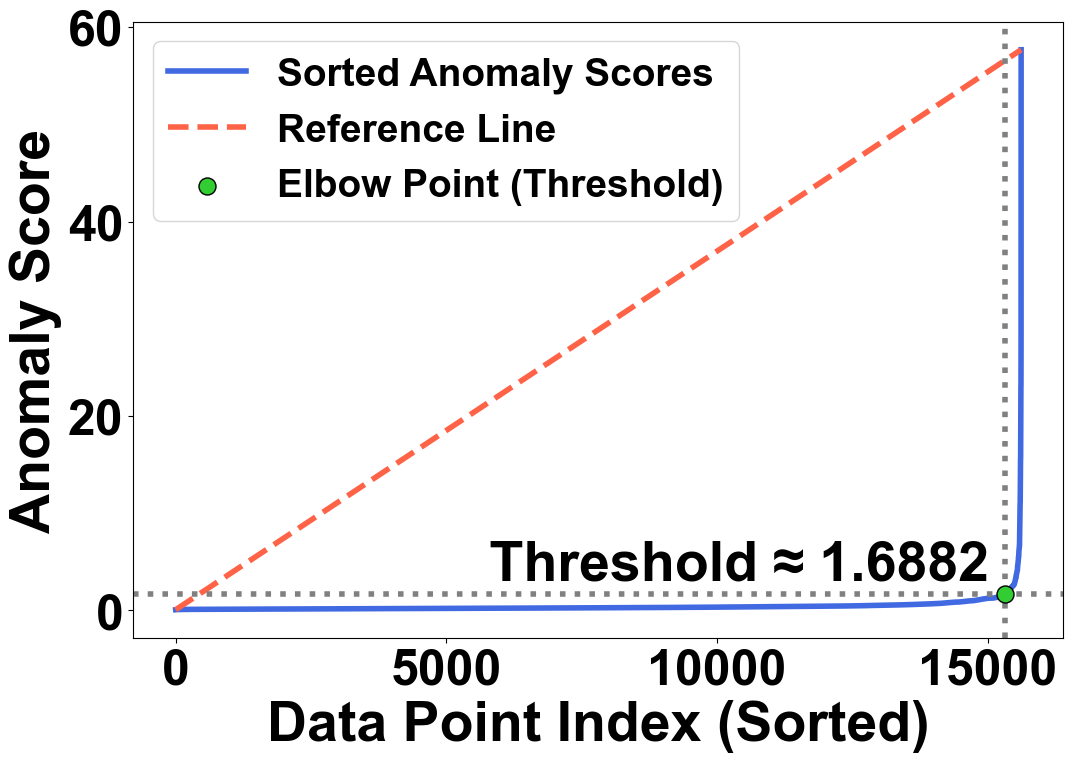

In [101]:
errors_train = np.mean(np.square(X_train.values - reconstructions_train), axis=1)
sorted_scores = np.sort(errors_train)
x_elbow = np.arange(len(sorted_scores))
y_elbow = sorted_scores
p1, p2 = np.array([x_elbow[0], y_elbow[0]]), np.array([x_elbow[-1], y_elbow[-1]])
dist_to_line = np.abs(np.cross(p2 - p1, p1 - np.array([x_elbow, y_elbow]).T)) / np.linalg.norm(p2 - p1)
anomaly_threshold = y_elbow[np.argmax(dist_to_line)]
print(f"Calculated Anomaly Threshold: {anomaly_threshold:.4f}")
np.save(f'{output_dir}/anomaly_threshold_{latent_dim}_{step_size}.npy',anomaly_threshold)
np.save(f'{output_dir}/sorted_scores_{latent_dim}_{step_size}.npy',sorted_scores)
##############################################################

x = np.arange(len(sorted_scores))
y = sorted_scores
elbow_index = np.argmax(dist_to_line)
np.save(f'{output_dir}/elbow_index_{latent_dim}_{step_size}.npy',elbow_index)


figg, axx = plt.subplots(figsize=(12, 8))

axx.plot(x, y, label='Sorted Anomaly Scores', color='royalblue', linewidth=4)
axx.plot([x[0], x[-1]], [y[0], y[-1]], 'r--', label='Reference Line', color='tomato',linewidth=4)
axx.scatter(elbow_index, anomaly_threshold, color='limegreen', s=150, zorder=5, 
            edgecolor='black', label='Elbow Point (Threshold)')

axx.axhline(y=anomaly_threshold, color='grey', linestyle=':', linewidth=4)
axx.axvline(x=elbow_index, color='grey', linestyle=':', linewidth=4)

axx.set_xlabel('Data Point Index (Sorted)', color='k')
axx.set_ylabel('Anomaly Score',color='k' )
axx.legend(prop={'size': 7*m,  'weight': 'bold'})

axx.text(elbow_index*0.98, anomaly_threshold*1.2, f' Threshold ≈ {anomaly_threshold:.4f}', 
         horizontalalignment='right', verticalalignment='bottom', fontsize=m*10,color='k')
figg.savefig(f'Figures/elbow_{latent_dim}_{step_size}.pdf')

#################################################################


############################################
#reconstructions_test = autoencoder.predict(X_test.values, verbose=0)
errors_test = np.mean(np.square(X_test.values - reconstructions_test), axis=1)
predicted_labels = (errors_test > anomaly_threshold)



reducer_95 = PCA(n_components=0.95, random_state=0)
reducer_95.fit(X_train[features])
embedding_pca_95 = reducer_95.transform(X_test[features])
n_components_95 = reducer_95.n_components_

normal_pca_95 = embedding_pca_95[~predicted_labels]
anomaly_pca_95 = embedding_pca_95[predicted_labels]

maha_dist_ratio_95 = 0.0
if normal_pca_95.shape[0] > 1 and anomaly_pca_95.shape[0] > 0:
    # --- Metric 1: Mahalanobis Distance Ratio (UPGRADED) ---
    centroid_95 = np.mean(normal_pca_95, axis=0)
    # Calculate covariance and its inverse for the normal data
    cov_matrix_95 = np.cov(normal_pca_95, rowvar=False)
    inv_cov_matrix_95 = np.linalg.inv(cov_matrix_95)
    
    # Calculate Mahalanobis distance for each point
    maha_dist_normal = [mahalanobis(p, centroid_95, inv_cov_matrix_95) for p in normal_pca_95]
    maha_dist_anomaly = [mahalanobis(p, centroid_95, inv_cov_matrix_95) for p in anomaly_pca_95]
    
    avg_maha_normal = np.mean(maha_dist_normal)
    avg_maha_anomaly = np.mean(maha_dist_anomaly)
    maha_dist_ratio_95 = avg_maha_anomaly / avg_maha_normal if avg_maha_normal > 0 else 0
print(maha_dist_ratio_95)

reducer_2d = PCA(n_components=2, random_state=0)
embedding_pca_2d = reducer_2d.fit_transform(X_full_dataset)

errors_full = np.mean(np.square(X_full_dataset.values - reconstructions_full), axis=1)



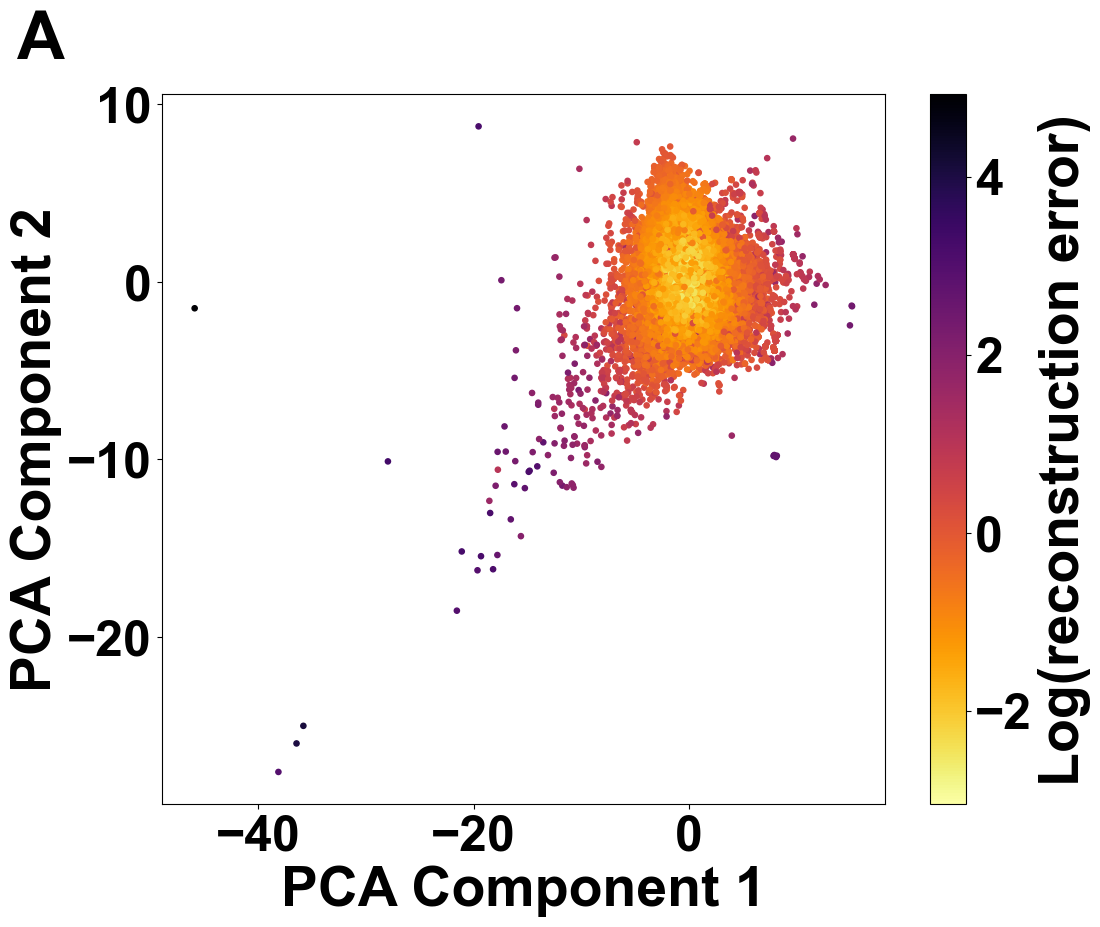

In [102]:
fig, ax = plt.subplots(figsize=(12, 10)) # Increased width slightly for colorbar

# Capture the scatter plot object in a variable called 'scatter'
scatter = ax.scatter(
    embedding_pca_2d[:, 0],
    embedding_pca_2d[:, 1],
    c=np.log(errors_full),
    s=14,
    alpha=1,
    cmap='inferno_r'
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Log(reconstruction error)", fontweight='bold') # Set a descriptive label

ax.set_xlabel("PCA Component 1", fontweight='bold')
ax.set_ylabel("PCA Component 2", fontweight='bold')
ax.grid(False)



plt.tight_layout(rect=[0, 0, 1, 0.95]) # rect=[left, bottom, right, top]
ax.text(-0.2, 1.05, 'A', transform=ax.transAxes,fontsize=m*12,  fontweight='bold')

plt.savefig(f'Dimention Reduction/PCA_full_colored_{latent_dim}_{step_size}.pdf')
plt.show()

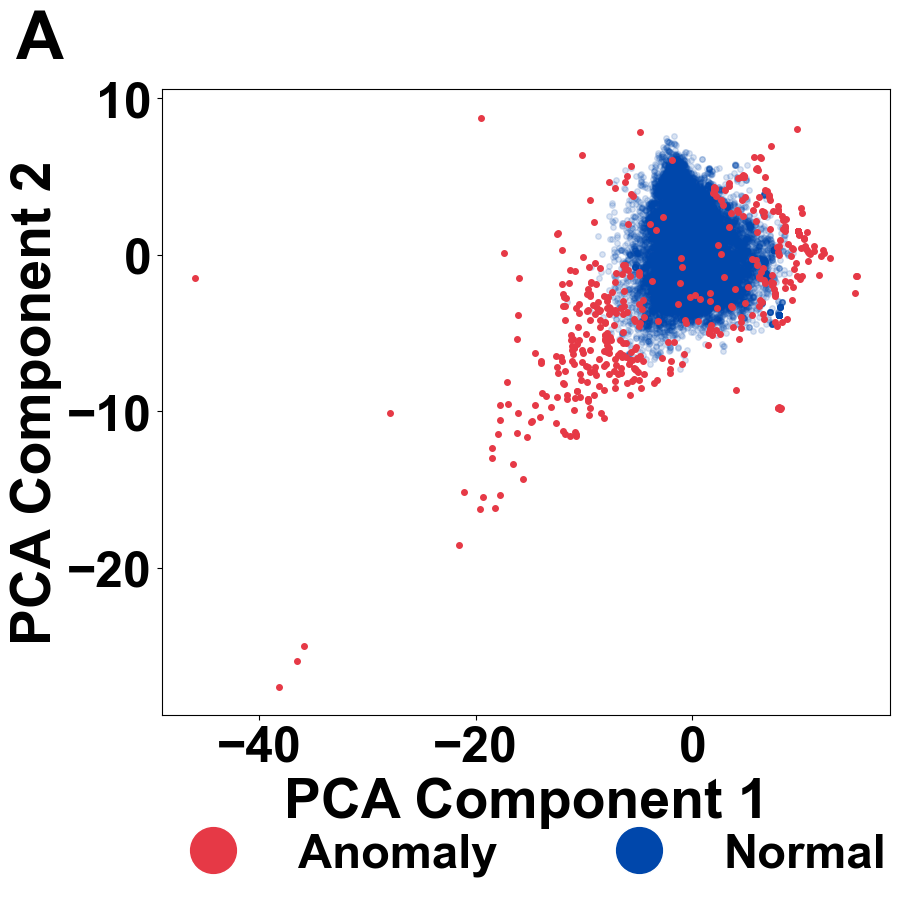

In [103]:
errors_full= np.mean(np.square(X_full_dataset.values - reconstructions_full), axis=1)
predicted_labels = (errors_full > anomaly_threshold)
normal_pca_2d = embedding_pca_2d[~predicted_labels]
anomaly_pca_2d = embedding_pca_2d[predicted_labels]


fig, ax = plt.subplots(figsize=(10, 10))

# Define the new, more vivid colors
normal_color = "#0047AB"    # strong cobalt blue
anomaly_color = "#E63946"   # vivid red (high contrast)


# Plot the data points
ax.scatter(normal_pca_2d[:, 0], normal_pca_2d[:, 1], c=normal_color, s=16, alpha=0.15)
ax.scatter(anomaly_pca_2d[:, 0], anomaly_pca_2d[:, 1], c=anomaly_color, s=16, alpha=1)

# Set labels and ticks
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.tick_params(axis='both', which='major',color='k')

# Create the legend with the updated colors
legend_elements = [
   Line2D([0], [0], marker='o', color='w', label='Anomaly',
          markerfacecolor=anomaly_color, markersize=35),
   Line2D([0], [0], marker='o', color='w', label='Normal',
          markerfacecolor=normal_color, markersize=35),
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    fontsize=34,
    frameon=False,
    ncols=2
)

plt.tight_layout(rect=[0, 0.0, 1, 0.95])
ax.text(-0.2, 1.05, 'A', transform=ax.transAxes,fontsize=m*12,  fontweight='bold')

ax.grid(False)
# Save the final figure
plt.savefig(f'Dimention Reduction/PCA_category_{latent_dim}_{step_size}.pdf')
plt.show()

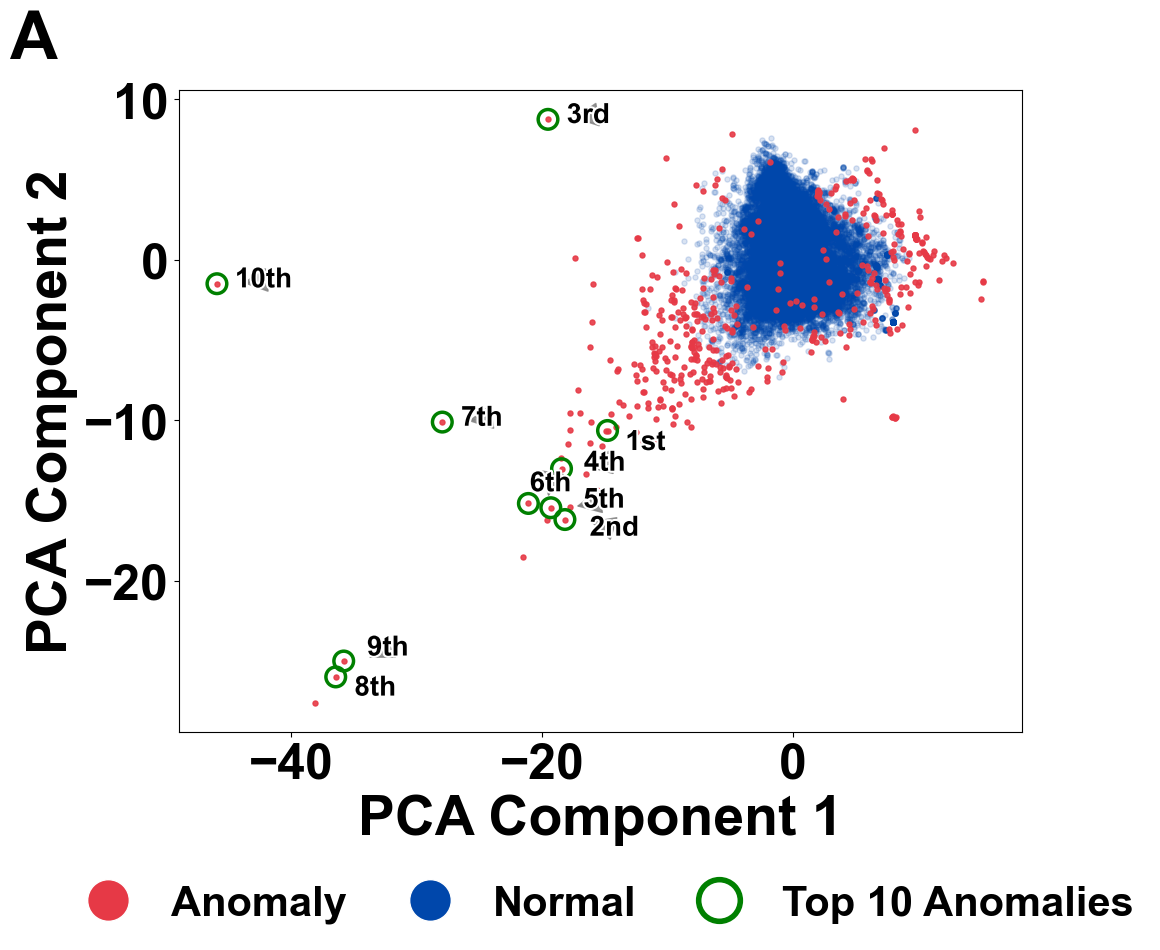

In [104]:
# Get reconstructions and compute anomaly scores
errors_full = np.mean(np.square(X_full_dataset.values - reconstructions_full), axis=1)
predicted_labels = (errors_full > anomaly_threshold)

# Separate points for plotting
normal_pca_2d = embedding_pca_2d[~predicted_labels]
anomaly_pca_2d = embedding_pca_2d[predicted_labels]

# === Identify Top 5 Anomalies ===
top_k = 10
top_indices = np.argsort(errors_full)[-top_k:]  # indices of top 5 anomalies
top_points = embedding_pca_2d[top_indices]
top_scores = errors_full[top_indices]

# === Plot ===
fig, ax = plt.subplots(figsize=(12, 10))

normal_color = "#0047AB"   # cobalt blue
anomaly_color = "#E63946"  # vivid red
ax.scatter(normal_pca_2d[:, 0], normal_pca_2d[:, 1],
           c=normal_color, s=14, alpha=0.15, label='Normal')
ax.scatter(anomaly_pca_2d[:, 0], anomaly_pca_2d[:, 1],
           c=anomaly_color, s=13, alpha=0.9, label='Anomaly')

# Highlight top 5 anomalies with a larger marker
ax.scatter(top_points[:, 0], top_points[:, 1],
           facecolors='none', edgecolors='green', s=200, linewidths=2.5, label='Top anomalies')

ss=['1st','2nd','3rd','4th','5th','6th','7th','8th','9th','10th']

# === Annotate each top anomaly ===
texts = []
# A small value to offset the text from the point initially
x_offset = 1.5

for i, idx in enumerate(top_indices):
    x, y = top_points[i]
    txt = ax.text(
        x + x_offset,  # Start the text slightly to the right of the point ### CHANGE ###
        y,
        f"{ss[i]}",
        fontsize=20,
        fontweight='bold',
        color='black',
        zorder=10,
        ha='left',     # Align the left of the text with the coordinate ### CHANGE ###
        va='center',   # Keep it vertically centered
        path_effects=[pe.withStroke(linewidth=3, foreground="white")] # white halo for readability
    )
    texts.append(txt)

# === Adjust text positions intelligently ===
adjust_text(
    texts,
    expand_points=(2.0, 2.0),     # push text further away from markers
    expand_text=(1.2, 1.4),
    arrowprops=dict(
        arrowstyle="-|>",         # clean arrow with small tip
        color="gray",
        lw=1.2,
        alpha=0.8,
        shrinkA=5,
        shrinkB=5
    ),
    force_text=0.6,               # stronger push between texts
    force_points=0.6,
    only_move={'points': 'y', 'text': 'xy'}, # constrain movement for clarity
    ax=ax
)


# === Labels and Legend ===
ax.set_xlabel("PCA Component 1", )
ax.set_ylabel("PCA Component 2", )
ax.tick_params(axis='both',)
ax.grid(False)

# Custom legend
legend_elements = [
   Line2D([0], [0], marker='o', color='w', label='Anomaly',
          markerfacecolor=anomaly_color, markersize=15*2),
   Line2D([0], [0], marker='o', color='w', label='Normal',
          markerfacecolor=normal_color, markersize=15*2),
   Line2D([0], [0], marker='o', markeredgecolor='green', markerfacecolor='none',linestyle='None',
          label='Top 10 Anomalies', markersize=15*2, markeredgewidth=4 )
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    fontsize=30,
    frameon=False,
    ncols=3,
    # --- Parameters to make it 'tighter' ---
    
    # Adjust space between columns (default is 2.0)
    columnspacing=1.0,  
    
    # Adjust vertical space between entries (default is 0.5)
    labelspacing=0.2,   
    
    # Adjust space between the handle (color) and the text (default is 0.8)
    handletextpad=0.5
)


plt.tight_layout(rect=[0, 0.0, 1, 1]) # rect=[left, bottom, right, top]
ax.text(-0.2, 1.05, 'A', transform=ax.transAxes,fontsize=m*12,  fontweight='bold')


plt.savefig(f'Dimention Reduction/PCA_category_with_top10_{latent_dim}_{step_size}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [98]:
shayan=X_full_dataset.copy()
shayan['anomaly_score']=errors_full
allerrors=pd.DataFrame(np.square(X_full_dataset.values - reconstructions_full))
allerrors.columns=features
for feat in features:
    shayan[f'anomaly_score_{feat}']=allerrors[feat]

df_sorted = shayan.sort_index()
for col in df_cleaned.columns:
    if col=='index':
        continue
    df_sorted[col]=df_cleaned[col]

df_sorted.to_csv(f'df_all_anomalies.csv')
shayan.to_csv(f'scaled_df_all_anomalies.csv')

In [99]:
reducer_full = PCA(random_state=0)
reducer_full.fit(X_full_dataset)
profile=reducer_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(profile)

In [100]:
cumulative_explained_variance

array([0.22935409, 0.40481154, 0.54070117, 0.60874158, 0.66114741,
       0.7022453 , 0.74124556, 0.77447145, 0.80421907, 0.82963298,
       0.852654  , 0.87242381, 0.89021959, 0.90509627, 0.91807275,
       0.9300161 , 0.93920264, 0.9476555 , 0.95391359, 0.95956497,
       0.96464252, 0.96900272, 0.97314483, 0.97686368, 0.9803995 ,
       0.98357602, 0.9857028 , 0.98758061, 0.98927573, 0.99070734,
       0.99196571, 0.99297944, 0.99383514, 0.99460539, 0.99524907,
       0.99580771, 0.99629646, 0.99667276, 0.99696405, 0.99723049,
       0.99749185, 0.99773425, 0.99793157, 0.99811916, 0.99829856,
       0.99847143, 0.99864015, 0.99879633, 0.99892828, 0.99905473,
       0.9991752 , 0.99927573, 0.99936574, 0.99944944, 0.99951053,
       0.99955994, 0.99960648, 0.99964915, 0.99968966, 0.99972689,
       0.99976132, 0.99979187, 0.99982138, 0.99984688, 0.9998704 ,
       0.99989321, 0.99991513, 0.99993459, 0.99994984, 0.99996213,
       0.99997235, 0.9999821 , 0.99998886, 0.99999451, 1.     